# Woodbury Solve Step by Step

The Woodbury matrix identity turns an $n \times n$ solve into
a cheap $k \times k$ solve when the matrix has low-rank structure:

$$(L + U D V^\top)^{-1} = L^{-1} - L^{-1} U \, C^{-1} \, V^\top L^{-1}$$

where $C = D^{-1} + V^\top L^{-1} U$ is the $k \times k$ **capacitance matrix**.

This notebook walks through each step and shows that `gaussx.solve`
does it automatically.

## Background

The Woodbury identity (also known as the matrix inversion lemma or
Sherman-Morrison-Woodbury formula) is one of the most important identities
in computational linear algebra. It appears in:

- **Sparse GP inference** — the Nystrom approximation yields a low-rank + diagonal
  covariance, and the Woodbury identity turns the $n \times n$ inversion into
  a $k \times k$ problem where $k \ll n$.
- **Kalman filtering** — sequential rank-1 updates to the state covariance
  are applied via the matrix inversion lemma at each time step.
- **Online learning** — rank-1 covariance updates (e.g. recursive least squares)
  use the Sherman-Morrison special case.
- **Ridge regression with feature space formulations** — the kernel trick
  relates the $n \times n$ and $p \times p$ solutions through Woodbury.

The identity was first published by Woodbury (1950) and independently by
Sherman & Morrison (1950) for the rank-1 case.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

/home/azureuser/localfiles/gaussx/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

We construct $A = \mathrm{diag}(d) + U U^\top$ where $d \in \mathbb{R}^{100}$
and $U \in \mathbb{R}^{100 \times 3}$ (rank 3).

In [2]:
key = jax.random.PRNGKey(0)
k1, k2, k3 = jax.random.split(key, 3)

n, rank = 100, 3
d = jnp.abs(jax.random.normal(k1, (n,))) + 0.5  # positive diagonal
U = jax.random.normal(k2, (n, rank)) * 0.5
b = jax.random.normal(k3, (n,))

# Build operator
sigma = gaussx.low_rank_plus_diag(d, U)
print(f"Operator: diag({n}) + rank-{rank} update")
print(f"  Full matrix size: {n}x{n} = {n**2:,} entries")
print(f"  Low-rank storage: {n} + {n}x{rank} = {n + n * rank:,} entries")

Operator: diag(100) + rank-3 update
  Full matrix size: 100x100 = 10,000 entries
  Low-rank storage: 100 + 100x3 = 400 entries


## Step-by-step Woodbury

In [3]:
# Step 1: L^{-1} b  (cheap — diagonal solve)
Linv_b = b / d
print("Step 1: L^{-1} b  — diagonal solve, O(n)")

# Step 2: L^{-1} U  (k diagonal solves)
Linv_U = U / d[:, None]
print(f"Step 2: L^{{-1}} U  — {rank} diagonal solves, O(nk)")

# Step 3: Capacitance matrix C = I + U^T L^{-1} U  (k x k)
C = jnp.eye(rank) + U.T @ Linv_U
print(f"Step 3: C = I + U^T L^{{-1}} U  — {rank}x{rank} matrix")

# Step 4: Solve C z = U^T L^{-1} b  (k x k dense solve)
z = jnp.linalg.solve(C, U.T @ Linv_b)
print(f"Step 4: C^{{-1}} (V^T L^{{-1}} b)  — {rank}x{rank} solve")

# Step 5: x = L^{-1} b - L^{-1} U z
x_woodbury = Linv_b - Linv_U @ z
print("Step 5: x = L^{-1} b - L^{-1} U z  — final answer")

Step 1: L^{-1} b  — diagonal solve, O(n)
Step 2: L^{-1} U  — 3 diagonal solves, O(nk)


Step 3: C = I + U^T L^{-1} U  — 3x3 matrix
Step 4: C^{-1} (V^T L^{-1} b)  — 3x3 solve


Step 5: x = L^{-1} b - L^{-1} U z  — final answer


## Verify against gaussx.solve

In [4]:
x_gaussx = gaussx.solve(sigma, b)
x_dense = jnp.linalg.solve(sigma.as_matrix(), b)

print(f"Woodbury vs dense:  max|diff| = {jnp.max(jnp.abs(x_woodbury - x_dense)):.2e}")
print(f"gaussx  vs dense:   max|diff| = {jnp.max(jnp.abs(x_gaussx - x_dense)):.2e}")
print(f"Woodbury vs gaussx: max|diff| = {jnp.max(jnp.abs(x_woodbury - x_gaussx)):.2e}")

Woodbury vs dense:  max|diff| = 5.55e-15
gaussx  vs dense:   max|diff| = 5.55e-15
Woodbury vs gaussx: max|diff| = 0.00e+00


## Matrix determinant lemma

Similarly, the logdet decomposes. This follows from the identity

$$|A + UDV^\top| = |D^{-1} + V^\top A^{-1} U| \cdot |D| \cdot |A|$$

which is a direct consequence of the Schur complement determinant identity.
Taking logarithms:

$$\log|A + UDV^\top| = \log|A| + \log|C| + \log|D|$$

where $C = D^{-1} + V^\top A^{-1} U$ is the capacitance matrix.
In our case ($D = I$, $V = U$):

In [5]:
ld_gaussx = gaussx.logdet(sigma)
ld_dense = jnp.linalg.slogdet(sigma.as_matrix())[1]

print(f"gaussx logdet:  {ld_gaussx:.6f}")
print(f"dense logdet:   {ld_dense:.6f}")
print(f"match: {jnp.allclose(ld_gaussx, ld_dense, rtol=1e-10)}")

gaussx logdet:  27.039277
dense logdet:   27.039277
match: True


## Visualizing the decomposition

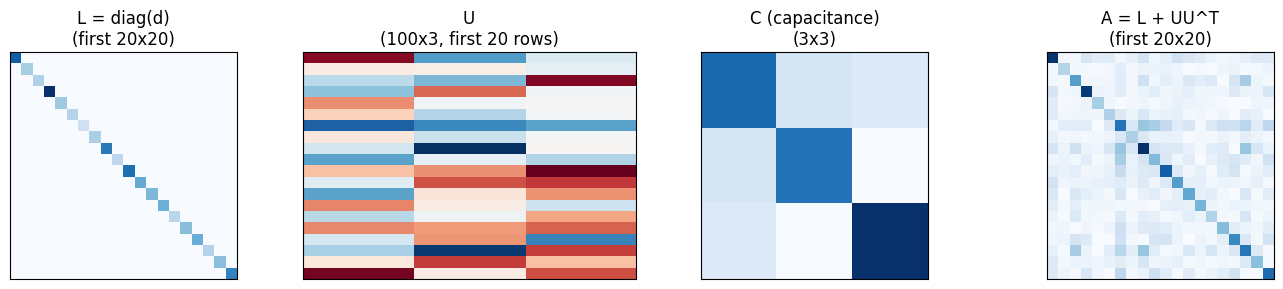

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(jnp.diag(d[:20]), cmap="Blues", interpolation="nearest")
axes[0].set_title("L = diag(d)\n(first 20x20)")

axes[1].imshow(U[:20], cmap="RdBu", interpolation="nearest", aspect="auto")
axes[1].set_title(f"U\n({n}x{rank}, first 20 rows)")

axes[2].imshow(C, cmap="Blues", interpolation="nearest")
axes[2].set_title(f"C (capacitance)\n({rank}x{rank})")

mat_20 = jnp.abs(sigma.as_matrix()[:20, :20])
axes[3].imshow(mat_20, cmap="Blues", interpolation="nearest")
axes[3].set_title("A = L + UU^T\n(first 20x20)")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cost comparison

| Operation | Dense | Woodbury |
|-----------|-------|----------|
| Solve | O(n^3) | O(nk^2 + k^3) |
| Logdet | O(n^3) | O(nk^2 + k^3) |
| Storage | O(n^2) | O(nk) |

For n=100, k=3: dense does ~10^6 ops, Woodbury does ~900.

## References

- Hager, W. W. (1989). Updating the inverse of a matrix.
  *SIAM Review*, 31(2), 221--239.
- Henderson, H. V. & Searle, S. R. (1981). On deriving the inverse of a
  sum of matrices. *SIAM Review*, 23(1), 53--60.
- Woodbury, M. A. (1950). *Inverting Modified Matrices*. Statistical Research
  Group Memo Report 42, Princeton University.